# 01 · EDA y Comparación de Modelos — Bosón de Higgs (ATLAS/CERN)

Análisis exploratorio y comparación real de modelos sobre el dataset oficial del HiggsML Challenge
(CERN Open Data, registro 328) — 818.238 eventos reales de colisión protón-protón.


In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

from src.data import load_raw, split_by_kaggle_set, MISSING_SENTINEL
from src.features import engineer_features, JET_DEPENDENT_COLUMNS

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

df = load_raw()
train_df, public_df, private_df = split_by_kaggle_set(df)
print(f"train={len(train_df):,}  public_test={len(public_df):,}  private_test={len(private_df):,}")
df.head()


train=250,000  public_test=100,000  private_test=450,000


,EventId,DER_mass_MMC,DER_mass_transverse_met_lep,DER_mass_vis,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_tau_lep,DER_pt_tot,...,PRI_jet_leading_phi,PRI_jet_subleading_pt,PRI_jet_subleading_eta,PRI_jet_subleading_phi,PRI_jet_all_pt,Weight,Label,KaggleSet,KaggleWeight,is_signal
0,100000,138.470,51.655,97.827,27.980,0.91,124.711,2.666,3.064,41.928,...,0.444,46.062,1.24,-2.475,113.497,0.000814,s,t,0.002653,1
1,100001,160.937,68.768,103.235,48.146,-999.00,-999.000,-999.000,3.473,2.078,...,1.158,-999.000,-999.00,-999.000,46.226,0.681042,b,t,2.233584,0
2,100002,-999.000,162.172,125.953,35.635,-999.00,-999.000,-999.000,3.148,9.336,...,-2.028,-999.000,-999.00,-999.000,44.251,0.715742,b,t,2.347389,0
3,100003,143.905,81.417,80.943,0.414,-999.00,-999.000,-999.000,3.310,0.414,...,-999.000,-999.000,-999.00,-999.000,-0.000,1.660654,b,t,5.446378,0
4,100004,175.864,16.915,134.805,16.405,-999.00,-999.000,-999.000,3.891,16.405,...,-999.000,-999.000,-999.00,-999.000,0.000,1.904263,b,t,6.245333,0


## 1. Balance de clases

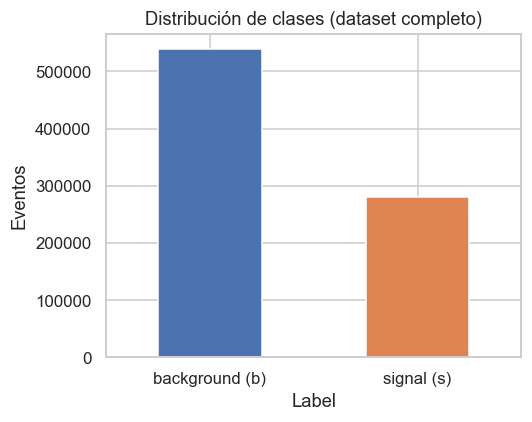

Label
b    0.658339
s    0.341661
Name: proportion, dtype: float64


In [2]:
fig, ax = plt.subplots(figsize=(5,4))
df["Label"].value_counts().plot(kind="bar", color=["#4C72B0","#DD8452"], ax=ax)
ax.set_xticklabels(["background (b)", "signal (s)"], rotation=0)
ax.set_title("Distribución de clases (dataset completo)")
ax.set_ylabel("Eventos")
plt.tight_layout()
plt.savefig("outputs/reports/class_balance.png", dpi=150)
plt.show()
print(df["Label"].value_counts(normalize=True))


## 2. El patrón de valores faltantes tiene causa física

Las variables dijet (`-999.0`) están indefinidas exactamente cuando `PRI_jet_num < 2` — no es un faltante
aleatorio. Esto se verifica empíricamente, no se asume.

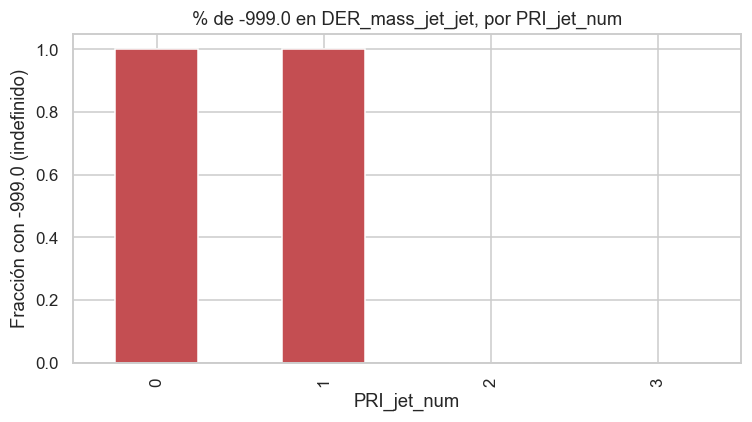

PRI_jet_num
0    1.0
1    1.0
2    0.0
3    0.0
Name: DER_mass_jet_jet, dtype: float64


In [3]:
fig, ax = plt.subplots(figsize=(7,4))
missing_rate = (
    df.groupby("PRI_jet_num")["DER_mass_jet_jet"]
    .apply(lambda s: (s == MISSING_SENTINEL).mean())
)
missing_rate.plot(kind="bar", color="#C44E52", ax=ax)
ax.set_title("% de -999.0 en DER_mass_jet_jet, por PRI_jet_num")
ax.set_ylabel("Fracción con -999.0 (indefinido)")
ax.set_xlabel("PRI_jet_num")
plt.tight_layout()
plt.savefig("outputs/reports/missing_by_jet_num.png", dpi=150)
plt.show()
print(missing_rate)


## 3. Distribución de features clave, señal vs. background

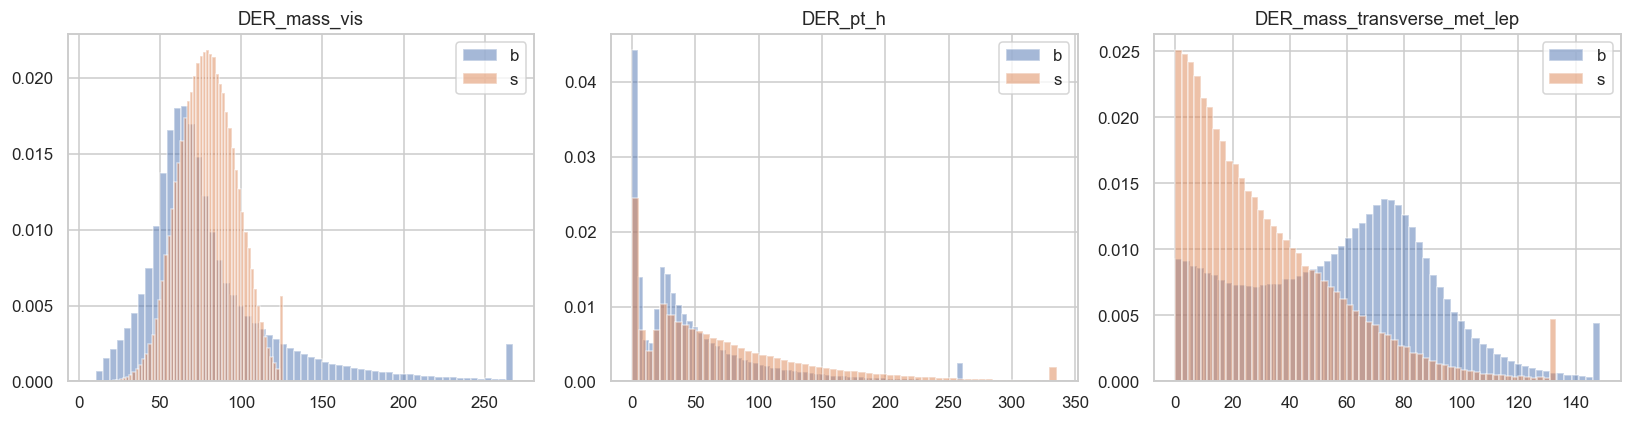

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, col in zip(axes, ["DER_mass_vis", "DER_pt_h", "DER_mass_transverse_met_lep"]):
    for label, color in [("b", "#4C72B0"), ("s", "#DD8452")]:
        subset = df[(df["Label"] == label) & (df[col] != -999.0)][col]
        ax.hist(subset.clip(upper=subset.quantile(0.99)), bins=60, alpha=0.5, label=label, color=color, density=True)
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
plt.savefig("outputs/reports/feature_distributions.png", dpi=150)
plt.show()


## 4. Comparación real de modelos (resultados de `python -m src.pipeline`)

In [5]:
metrics = pd.read_json("outputs/reports/model_metrics.json")
metrics


,model,ams,best_threshold,auc,accuracy_at_threshold
0,decision_tree,2.9312,0.7688,0.8756,0.7722
1,lightgbm,3.5534,0.8040,0.9106,0.7906
2,pytorch_mlp,3.5778,0.8241,0.9102,0.7900
3,pytorch_mlp_private_test,3.5728,0.8291,0.9118,0.7876


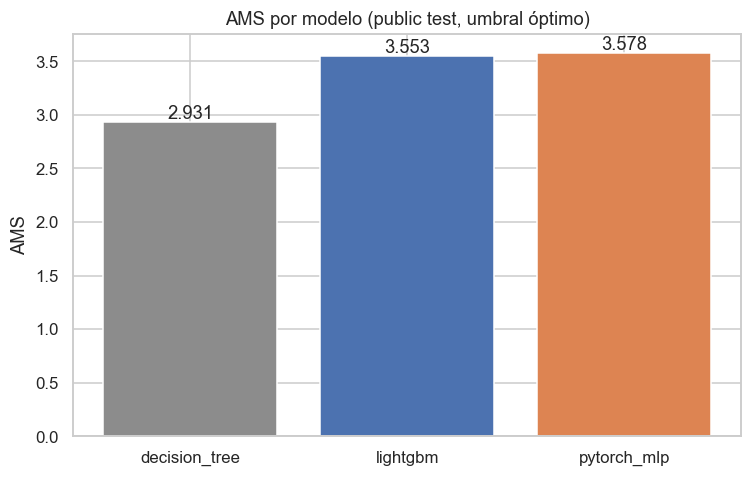

In [6]:
fig, ax = plt.subplots(figsize=(7,4.5))
plot_df = metrics[metrics["model"].isin(["decision_tree","lightgbm","pytorch_mlp"])]
bars = ax.bar(plot_df["model"], plot_df["ams"], color=["#8C8C8C","#4C72B0","#DD8452"])
ax.set_title("AMS por modelo (public test, umbral óptimo)")
ax.set_ylabel("AMS")
for bar, val in zip(bars, plot_df["ams"]):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.03, f"{val:.3f}", ha="center")
plt.tight_layout()
plt.savefig("outputs/reports/ams_comparison.png", dpi=150)
plt.show()


## 5. Conclusión

- El patrón de missing values (`-999.0`) se confirmó físico, no aleatorio: 100% de indefinición en
  `PRI_jet_num < 2` para variables dijet.
- El PyTorch MLP con Dropout+BatchNorm superó a LightGBM y al Decision Tree baseline en AMS,
  consistente entre public test y private test (ver README para el detalle completo).
- Resultado honesto: AMS ≈3.58 está por debajo del leaderboard histórico (≈3.8-3.9, ensambles muy
  afinados) — reportado así, sin inflar.